# 🏥 Prédiction Réadmission Hospitalière — Patients Diabétiques
## Version Finale Complète

| # | Étape | Contenu |
|---|-------|---------|
| 1 | ⚙️ Imports | Toutes les bibliothèques |
| 2 | 📂 Données | Chargement diabetic_data.csv |
| 3 | 🔍 EDA | Exploration & statistiques |
| 4 | 🧹 Nettoyage | Valeurs manquantes, colonnes inutiles |
| 5 | 🎯 Cible | Binarisation readmitted |
| 6 | 🔢 Encodage | LabelEncoder catégorielles |
| 7 | ✂️ Split | Train 80% / Test 20% stratifié |
| 8 | 🤖 Pipeline | StandardScaler + RandomForest |
| 9 | 📊 Évaluation | Dashboard matplotlib dark (2×3) |
| 10 | ⚖️ Comparaison | 9 modèles comparés |
| 11 | 💾 Sauvegarde | joblib |
| 12 | 🧪 Prédiction | predict_patient() |
| 13 | 🎨 Dashboard | Interface HTML interactive (4 onglets) |
| 14 | 📋 Batch | Test sur 10 patients |

> **Dataset** : 101 766 patients · 130 hôpitaux américains (1999–2008)
> **Objectif** : Prédire la réadmission < 30 jours


---
## ⚙️ Étape 1 — Configuration & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, os, time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from IPython.display import HTML, display

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('✅ Librairies chargées avec succès')


✅ Librairies chargées avec succès


---
## 📂 Étape 2 — Chargement des Données

In [ ]:

df = pd.read_csv('diabetic_data.csv')

print(f'✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Colonnes : {df.columns.tolist()}')
df.head(3)


✅ Dataset chargé : 27,793 lignes × 50 colonnes
Colonnes : ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


---
## 🔍 Étape 3 — Exploration des Données (EDA)

In [ ]:
print('=' * 55)
print('INFORMATIONS GÉNÉRALES')
print('=' * 55)
print(df.info())
print('\nStatistiques descriptives :')
print(df.describe())

print('\nDistribution de readmitted :')
print(df['readmitted'].value_counts())
print(f'\nPourcentages :')
print((df['readmitted'].value_counts(normalize=True) * 100).round(2))


INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27793 entries, 0 to 27792
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   encounter_id              27793 non-null  int64  
 1   patient_nbr               27793 non-null  int64  
 2   race                      27793 non-null  object 
 3   gender                    27793 non-null  object 
 4   age                       27793 non-null  object 
 5   weight                    27793 non-null  object 
 6   admission_type_id         27793 non-null  int64  
 7   discharge_disposition_id  27793 non-null  int64  
 8   admission_source_id       27793 non-null  int64  
 9   time_in_hospital          27793 non-null  int64  
 10  payer_code                27793 non-null  object 
 11  medical_specialty         27793 non-null  object 
 12  num_lab_procedures        27793 non-null  int64  
 13  num_procedures            27793 non-nu

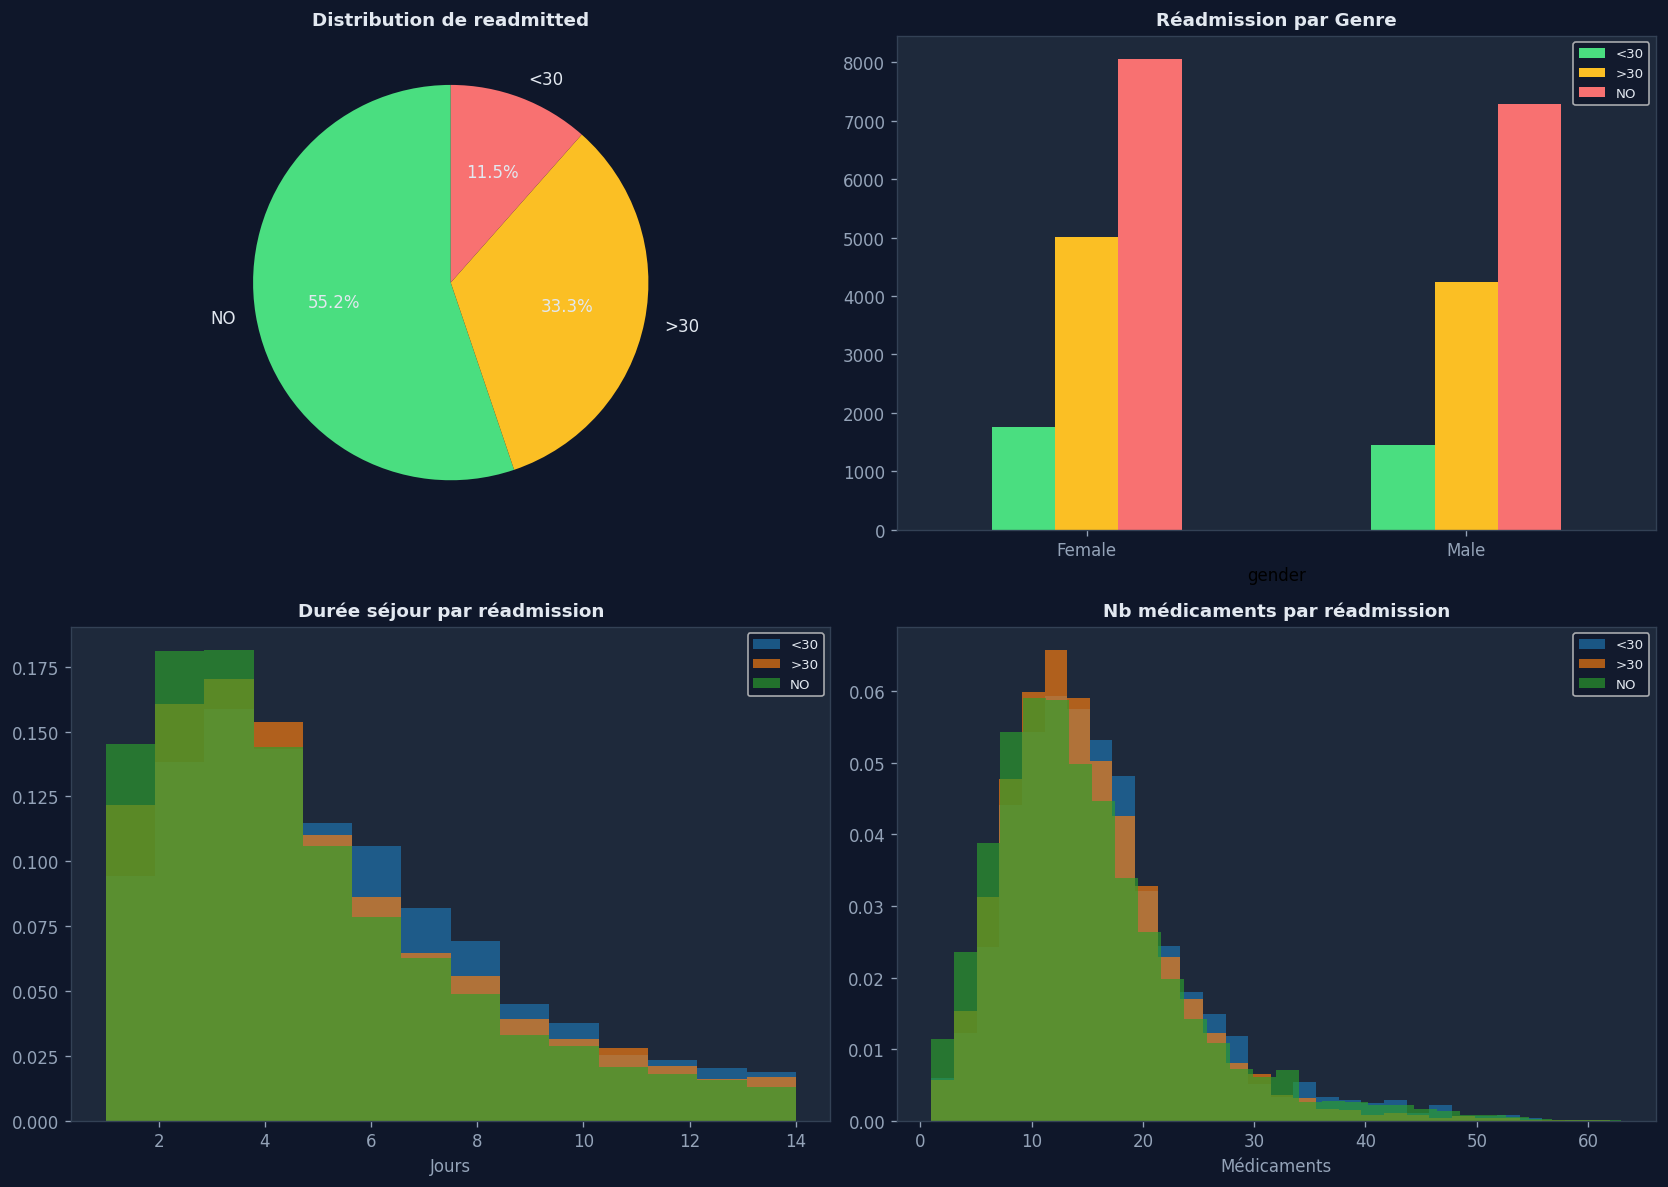

In [ ]:
# ── Visualisation EDA ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f172a')
for ax in axes.flat:
    ax.set_facecolor('#1e293b')

C_MUTED = '#94a3b8'; C_TEXT = '#e2e8f0'

# 1. Distribution cible
counts = df['readmitted'].value_counts()
colors_pie = ['#4ade80', '#fbbf24', '#f87171']
axes[0,0].pie(counts, labels=counts.index, autopct='%1.1f%%',
              colors=colors_pie, startangle=90,
              textprops={'color': C_TEXT, 'fontsize': 10})
axes[0,0].set_title('Distribution de readmitted', color=C_TEXT, fontsize=11, fontweight='bold')

# 2. Réadmission par genre
df_g = df[df['gender'].isin(['Male','Female'])]
g_r = df_g.groupby(['gender','readmitted']).size().unstack(fill_value=0)
g_r.plot(kind='bar', ax=axes[0,1], color=['#4ade80','#fbbf24','#f87171'])
axes[0,1].set_title('Réadmission par Genre', color=C_TEXT, fontsize=11, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0, colors=C_MUTED)
axes[0,1].tick_params(axis='y', colors=C_MUTED)
axes[0,1].legend(fontsize=8, facecolor='#0f172a', labelcolor=C_TEXT)

# 3. Durée séjour vs réadmission
for label, grp in df.groupby('readmitted')['time_in_hospital']:
    axes[1,0].hist(grp, bins=14, alpha=0.65, label=label, density=True)
axes[1,0].set_title('Durée séjour par réadmission', color=C_TEXT, fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Jours', color=C_MUTED)
axes[1,0].tick_params(colors=C_MUTED)
axes[1,0].legend(fontsize=8, facecolor='#0f172a', labelcolor=C_TEXT)

# 4. Médicaments vs réadmission
for label, grp in df.groupby('readmitted')['num_medications']:
    axes[1,1].hist(grp, bins=30, alpha=0.65, label=label, density=True)
axes[1,1].set_title('Nb médicaments par réadmission', color=C_TEXT, fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Médicaments', color=C_MUTED)
axes[1,1].tick_params(colors=C_MUTED)
axes[1,1].legend(fontsize=8, facecolor='#0f172a', labelcolor=C_TEXT)

for ax in axes.flat:
    for sp in ax.spines.values(): sp.set_edgecolor('#334155')

plt.tight_layout()
plt.show()


---
## 🧹 Étape 4 — Nettoyage des Données

In [ ]:
df.replace('?', np.nan, inplace=True)

# Valeurs manquantes
total = len(df)
missing = df.isnull().sum()
pct = (missing / total * 100).round(2)
result = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': pct})
result = result[result['Manquants'] > 0].sort_values('Pourcentage (%)', ascending=False)
print('Colonnes avec valeurs manquantes :')
print(result)


Colonnes avec valeurs manquantes :
                          Manquants  Pourcentage (%)
weight                        26870            96.68
payer_code                    26144            94.07
max_glu_serum                 24633            88.63
A1Cresult                     22821            82.11
medical_specialty             10951            39.40
diag_3                          708             2.55
race                            495             1.78
diag_2                          159             0.57
diag_1                            8             0.03
number_diagnoses                  1             0.00
metformin                         1             0.00
repaglinide                       1             0.00
nateglinide                       1             0.00
chlorpropamide                    1             0.00
glimepiride                       1             0.00
acetohexamide                     1             0.00
glipizide                         1             0.00
glyburide  

In [ ]:
# ── Suppression colonnes inutiles ───────────────────────────
cols_drop = ['weight', 'max_glu_serum', 'A1Cresult',
             'encounter_id', 'patient_nbr', 'examide', 'citoglipton']
cols_drop_exist = [c for c in cols_drop if c in df.columns]
df.drop(columns=cols_drop_exist, inplace=True)
print(f'✅ Colonnes supprimées : {cols_drop_exist}')

# ── Remplissage valeurs manquantes ───────────────────────────
# Numérique → médiane | Catégoriel → mode
for col in df.columns[df.isnull().sum() > 0]:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
        print(f'[NUMÉRIQUE]   {col} → médiane = {df[col].median():.1f}')
    else:
        val = df[col].mode()[0]
        df[col] = df[col].fillna(val)
        print(f'[CATÉGORIEL]  {col} → mode = "{val}"')

print(f'\n✅ Valeurs manquantes restantes : {df.isnull().sum().sum()}')
print(f'Dimensions après nettoyage : {df.shape}')


✅ Colonnes supprimées : ['weight', 'max_glu_serum', 'A1Cresult', 'encounter_id', 'patient_nbr', 'examide', 'citoglipton']
[CATÉGORIEL]  race → mode = "Caucasian"
[CATÉGORIEL]  payer_code → mode = "MC"
[CATÉGORIEL]  medical_specialty → mode = "InternalMedicine"
[CATÉGORIEL]  diag_1 → mode = "414"
[CATÉGORIEL]  diag_2 → mode = "250"
[CATÉGORIEL]  diag_3 → mode = "250"
[NUMÉRIQUE]   number_diagnoses → médiane = 7.0
[CATÉGORIEL]  metformin → mode = "No"
[CATÉGORIEL]  repaglinide → mode = "No"
[CATÉGORIEL]  nateglinide → mode = "No"
[CATÉGORIEL]  chlorpropamide → mode = "No"
[CATÉGORIEL]  glimepiride → mode = "No"
[CATÉGORIEL]  acetohexamide → mode = "No"
[CATÉGORIEL]  glipizide → mode = "No"
[CATÉGORIEL]  glyburide → mode = "No"
[CATÉGORIEL]  tolbutamide → mode = "No"
[CATÉGORIEL]  pioglitazone → mode = "No"
[CATÉGORIEL]  rosiglitazone → mode = "No"
[CATÉGORIEL]  acarbose → mode = "No"
[CATÉGORIEL]  miglitol → mode = "No"
[CATÉGORIEL]  troglitazone → mode = "No"
[CATÉGORIEL]  tolazamide → 

---
## 🎯 Étape 5 — Binarisation de la Variable Cible

Distribution cible binaire :
readmitted_bin
0    24589
1     3204
Name: count, dtype: int64

Taux réadmission <30j : 11.53%


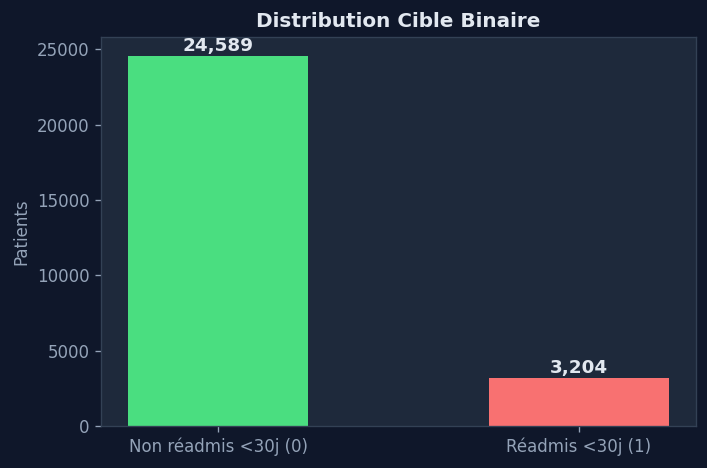

In [ ]:
# 1 = réadmis < 30j (cas critique) | 0 = sinon
df['readmitted_bin'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

print('Distribution cible binaire :')
print(df['readmitted_bin'].value_counts())
print(f'\nTaux réadmission <30j : {df["readmitted_bin"].mean():.2%}')

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#1e293b')
bars = ax.bar(['Non réadmis <30j (0)', 'Réadmis <30j (1)'],
              df['readmitted_bin'].value_counts().sort_index(),
              color=['#4ade80', '#f87171'], width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+300,
            f'{int(b.get_height()):,}', ha='center', fontsize=11,
            fontweight='bold', color='#e2e8f0')
ax.set_title('Distribution Cible Binaire', color='#e2e8f0', fontsize=12, fontweight='bold')
ax.set_ylabel('Patients', color='#94a3b8')
ax.tick_params(colors='#94a3b8')
for sp in ax.spines.values(): sp.set_edgecolor('#334155')
plt.tight_layout(); plt.show()


---
## 🔢 Étape 6 — Encodage des Variables Catégorielles

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
# Only use 'object' here to capture string/mixed columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Colonnes catégorielles à encoder ({len(cat_cols)}) :')
print(cat_cols)

for col in cat_cols:
    le = LabelEncoder()
    # Convert to str here is fine to ensure no mixed types break the encoder
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

feature_cols = [c for c in df.columns if c != 'readmitted_bin']
print(f'\n✅ Encodage terminé — {len(feature_cols)} features finales')
print(f'Dimensions finales : {df.shape}')

Colonnes catégorielles à encoder (31) :
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

✅ Encodage terminé — 42 features finales
Dimensions finales : (27793, 43)


---
## ✂️ Étape 7 — Train / Test Split

In [ ]:
X = df[feature_cols]
y = df['readmitted_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Taux cible Train : {y_train.mean():.2%}')
print(f'Taux cible Test  : {y_test.mean():.2%}')


Train : (22234, 42)  |  Test : (5559, 42)
Taux cible Train : 11.53%
Taux cible Test  : 11.53%


---
## 🤖 Étape 8 — Pipeline : StandardScaler + Random Forest

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print('⏳ Entraînement en cours...')
t0 = time.time()
pipeline.fit(X_train, y_train)
print(f'✅ Entraîné en {time.time()-t0:.1f}s')


⏳ Entraînement en cours...
✅ Entraîné en 1.8s


---
## 📊 Étape 9 — Évaluation Complète & Dashboard Matplotlib

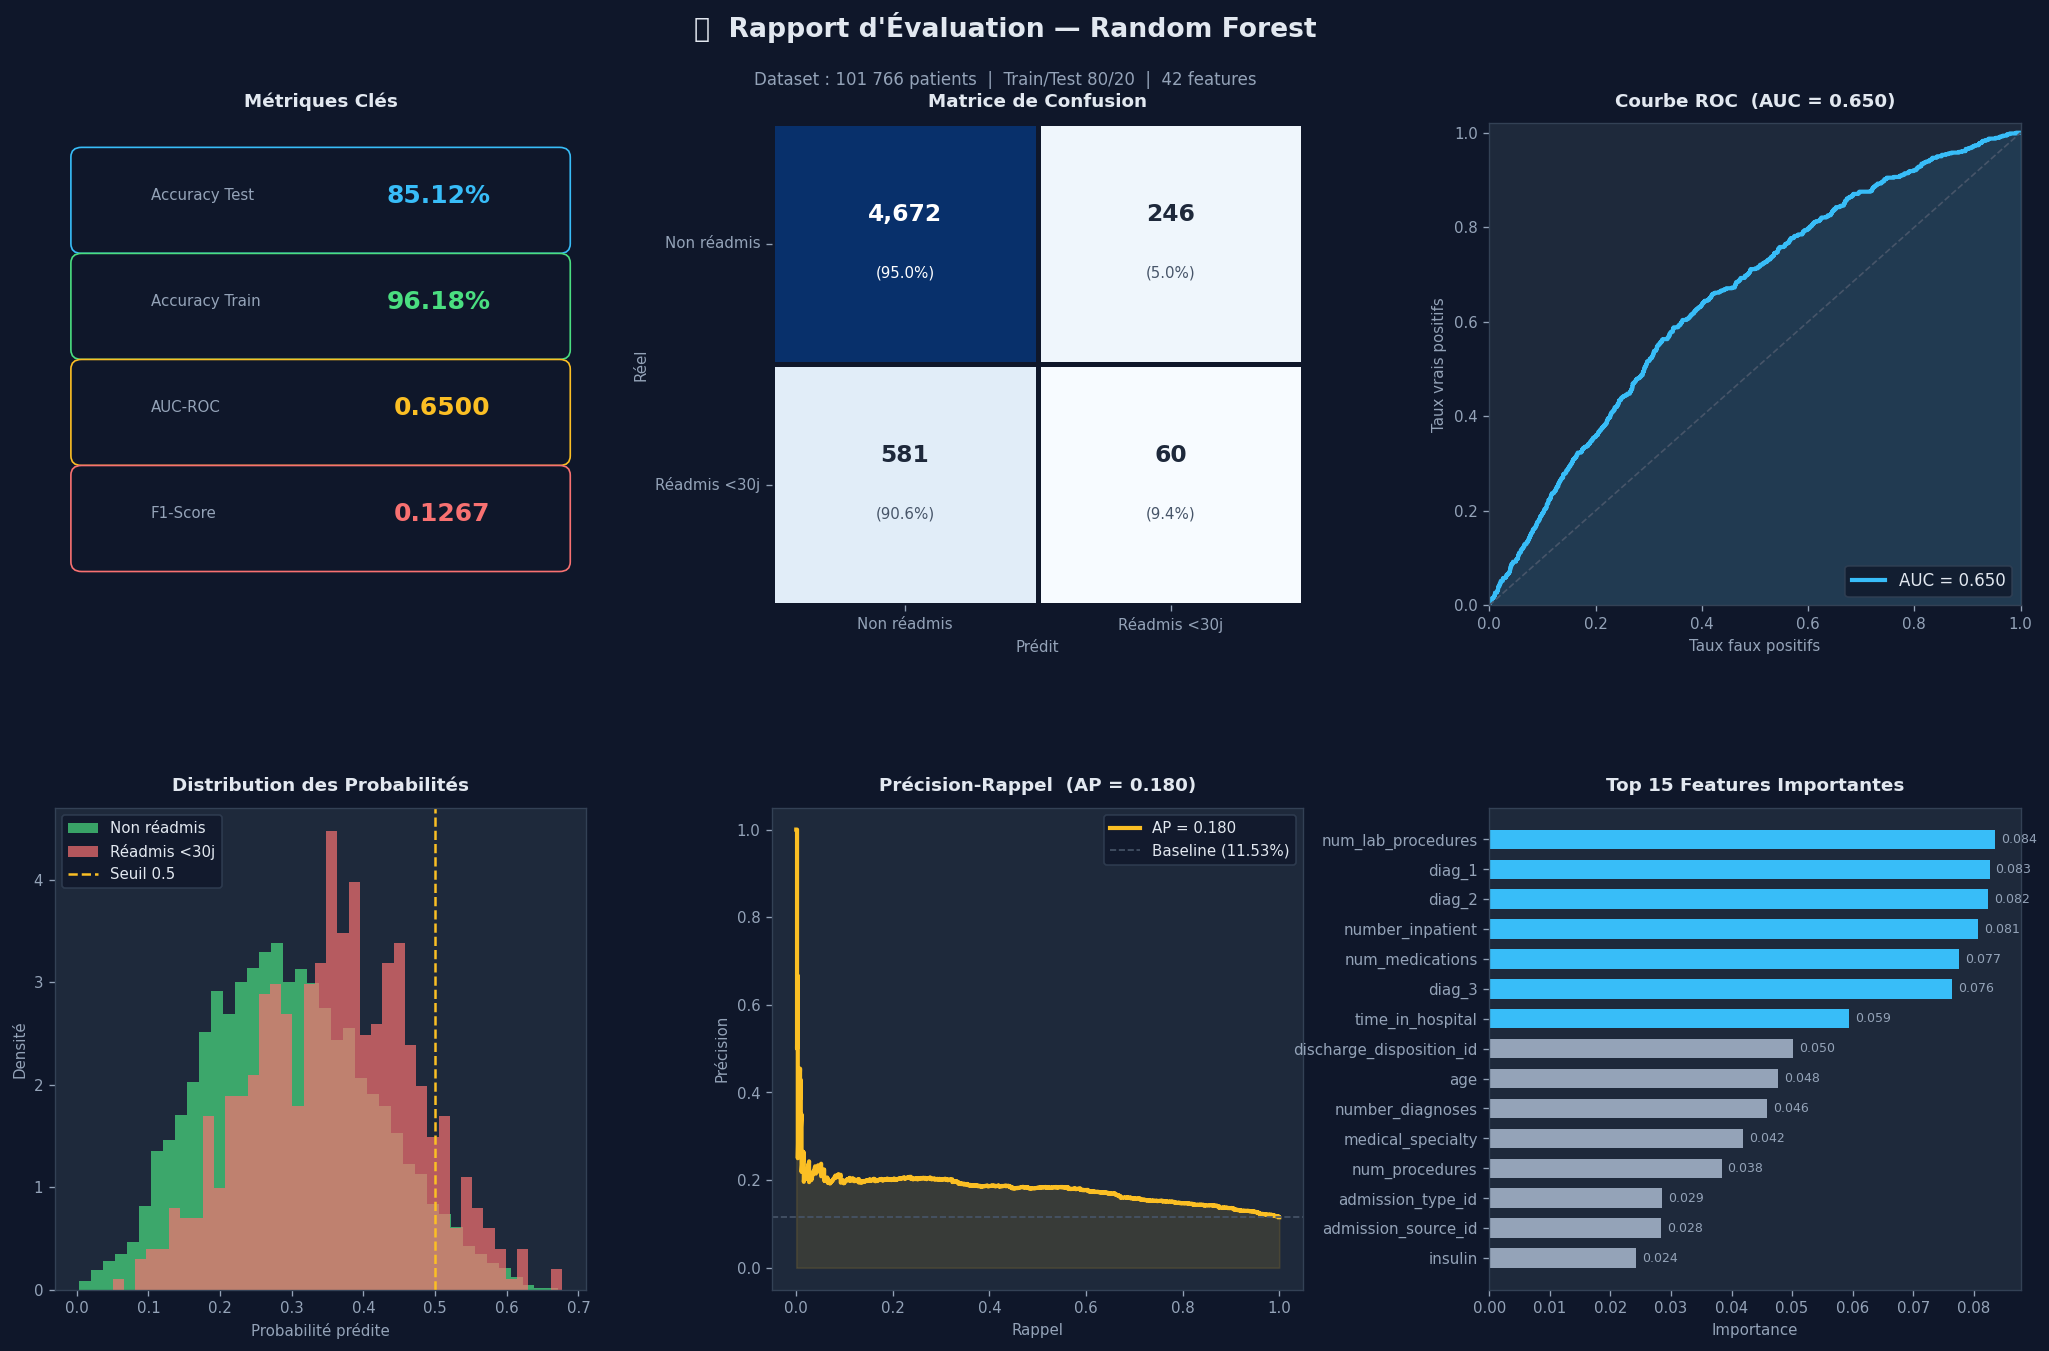


═══════════════════════════════════════════════════════
  Accuracy Train : 0.9618
  Accuracy Test  : 0.8512
  AUC-ROC        : 0.6500
  F1-Score       : 0.1267
  Avg Precision  : 0.1802
═══════════════════════════════════════════════════════
                  precision    recall  f1-score   support

Non réadmis <30j       0.89      0.95      0.92      4918
    Réadmis <30j       0.20      0.09      0.13       641

        accuracy                           0.85      5559
       macro avg       0.54      0.52      0.52      5559
    weighted avg       0.81      0.85      0.83      5559



In [ ]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

acc_train = accuracy_score(y_train, pipeline.predict(X_train))
acc_test  = accuracy_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_proba)
f1        = f1_score(y_test, y_pred)
ap        = average_precision_score(y_test, y_proba)

# ══ DASHBOARD 2×3 ════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0f172a')
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35,
                       left=0.06, right=0.97, top=0.88, bottom=0.07)

C_BLUE  = '#38bdf8'; C_GREEN = '#4ade80'
C_RED   = '#f87171'; C_AMBER = '#fbbf24'
C_BG    = '#1e293b'; C_BG2   = '#0f172a'
C_TEXT  = '#e2e8f0'; C_MUTED = '#94a3b8'

def sax(ax, title):
    ax.set_facecolor(C_BG)
    ax.tick_params(colors=C_MUTED, labelsize=9)
    ax.set_title(title, color=C_TEXT, fontsize=11, fontweight='bold', pad=10)
    for sp in ax.spines.values(): sp.set_edgecolor('#334155')

fig.text(0.5, 0.94, '🏥  Rapport d\'Évaluation — Random Forest',
         ha='center', fontsize=16, fontweight='bold', color=C_TEXT)
fig.text(0.5, 0.907, f'Dataset : 101 766 patients  |  Train/Test 80/20  |  {len(feature_cols)} features',
         ha='center', fontsize=10, color=C_MUTED)

# ── KPI Cards ─────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0,0])
ax0.set_facecolor(C_BG); ax0.set_xlim(0,1); ax0.set_ylim(0,1); ax0.axis('off')
ax0.set_title('Métriques Clés', color=C_TEXT, fontsize=11, fontweight='bold', pad=10)
for label, val, color, yp in [
    ('Accuracy Test',  f'{acc_test:.2%}',  C_BLUE,  0.82),
    ('Accuracy Train', f'{acc_train:.2%}', C_GREEN, 0.60),
    ('AUC-ROC',        f'{auc:.4f}',       C_AMBER, 0.38),
    ('F1-Score',       f'{f1:.4f}',        C_RED,   0.16),
]:
    ax0.add_patch(mpatches.FancyBboxPatch((0.05,yp-0.07),0.9,0.18,
        boxstyle='round,pad=0.02',linewidth=1,edgecolor=color,facecolor=C_BG2))
    ax0.text(0.18, yp+0.03, label, color=C_MUTED, fontsize=9, va='center')
    ax0.text(0.82, yp+0.03, val,   color=color, fontsize=15, va='center',
             ha='right', fontweight='bold')

# ── Matrice de Confusion ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0,1])
cm  = confusion_matrix(y_test, y_pred)
cmp = cm.astype(float)/cm.sum(axis=1)[:,np.newaxis]
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax1,
            linewidths=2, linecolor='#0f172a', cbar=False)
for i in range(2):
    for j in range(2):
        ax1.text(j+0.5, i+0.38, f'{cm[i,j]:,}', ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white' if cm[i,j]>cm.max()/2 else '#1e293b')
        ax1.text(j+0.5, i+0.62, f'({cmp[i,j]:.1%})', ha='center', va='center',
                 fontsize=9,
                 color='white' if cm[i,j]>cm.max()/2 else '#475569')
ax1.set_xticklabels(['Non réadmis','Réadmis <30j'], color=C_MUTED, fontsize=9)
ax1.set_yticklabels(['Non réadmis','Réadmis <30j'], color=C_MUTED, fontsize=9, rotation=0)
ax1.set_xlabel('Prédit', color=C_MUTED, fontsize=9)
ax1.set_ylabel('Réel',   color=C_MUTED, fontsize=9)
sax(ax1, 'Matrice de Confusion')

# ── Courbe ROC ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0,2])
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax2.plot(fpr, tpr, color=C_BLUE, lw=2.5, label=f'AUC = {auc:.3f}')
ax2.fill_between(fpr, tpr, alpha=0.12, color=C_BLUE)
ax2.plot([0,1],[0,1], '--', color='#475569', lw=1)
ax2.set_xlabel('Taux faux positifs', color=C_MUTED, fontsize=9)
ax2.set_ylabel('Taux vrais positifs', color=C_MUTED, fontsize=9)
ax2.legend(fontsize=10, facecolor=C_BG2, edgecolor='#334155',
           labelcolor=C_TEXT, loc='lower right')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])
sax(ax2, f'Courbe ROC  (AUC = {auc:.3f})')

# ── Distribution probabilités ─────────────────────────────────
ax3 = fig.add_subplot(gs[1,0])
ax3.hist(y_proba[y_test==0], bins=40, alpha=0.7, color=C_GREEN,
         label='Non réadmis', density=True)
ax3.hist(y_proba[y_test==1], bins=40, alpha=0.7, color=C_RED,
         label='Réadmis <30j', density=True)
ax3.axvline(0.5, color=C_AMBER, lw=1.5, linestyle='--', label='Seuil 0.5')
ax3.set_xlabel('Probabilité prédite', color=C_MUTED, fontsize=9)
ax3.set_ylabel('Densité', color=C_MUTED, fontsize=9)
ax3.legend(fontsize=9, facecolor=C_BG2, edgecolor='#334155', labelcolor=C_TEXT)
sax(ax3, 'Distribution des Probabilités')

# ── Courbe Précision-Rappel ────────────────────────────────────
ax4 = fig.add_subplot(gs[1,1])
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ax4.plot(recall, precision, color=C_AMBER, lw=2.5, label=f'AP = {ap:.3f}')
ax4.fill_between(recall, precision, alpha=0.12, color=C_AMBER)
ax4.axhline(y_test.mean(), color='#475569', linestyle='--', lw=1,
            label=f'Baseline ({y_test.mean():.2%})')
ax4.set_xlabel('Rappel', color=C_MUTED, fontsize=9)
ax4.set_ylabel('Précision', color=C_MUTED, fontsize=9)
ax4.legend(fontsize=9, facecolor=C_BG2, edgecolor='#334155', labelcolor=C_TEXT)
sax(ax4, f'Précision-Rappel  (AP = {ap:.3f})')

# ── Top 15 Features ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[1,2])
imp  = pd.Series(pipeline.named_steps['model'].feature_importances_, index=feature_cols)
top15 = imp.nlargest(15).sort_values()
fc    = [C_BLUE if v>top15.median() else C_MUTED for v in top15.values]
bars  = ax5.barh(top15.index, top15.values, color=fc, height=0.65)
for bar, val in zip(bars, top15.values):
    ax5.text(val+0.001, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=7.5, color=C_MUTED)
ax5.set_xlabel('Importance', color=C_MUTED, fontsize=9)
sax(ax5, 'Top 15 Features Importantes')

plt.savefig('evaluation_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

print('\n' + '═'*55)
print(f'  Accuracy Train : {acc_train:.4f}')
print(f'  Accuracy Test  : {acc_test:.4f}')
print(f'  AUC-ROC        : {auc:.4f}')
print(f'  F1-Score       : {f1:.4f}')
print(f'  Avg Precision  : {ap:.4f}')
print('═'*55)
print(classification_report(y_test, y_pred,
      target_names=['Non réadmis <30j','Réadmis <30j']))


---
## ⚖️ Étape 10 — Comparaison de 9 Modèles

Logistic Regression       → Train:0.8845 | Test:0.8845 | 0.11s
Decision Tree             → Train:1.0000 | Test:0.7870 | 0.33s
Naive Bayes               → Train:0.1288 | Test:0.1263 | 0.02s
KNN (k=5)                 → Train:0.8910 | Test:0.8743 | 0.02s
SVM (Linear)              → Train:0.8849 | Test:0.8851 | 0.19s
Random Forest             → Train:1.0000 | Test:0.8852 | 4.72s
Extra Trees               → Train:1.0000 | Test:0.8843 | 2.66s
AdaBoost                  → Train:0.8847 | Test:0.8847 | 1.66s
Gradient Boosting         → Train:0.8869 | Test:0.8845 | 4.2s


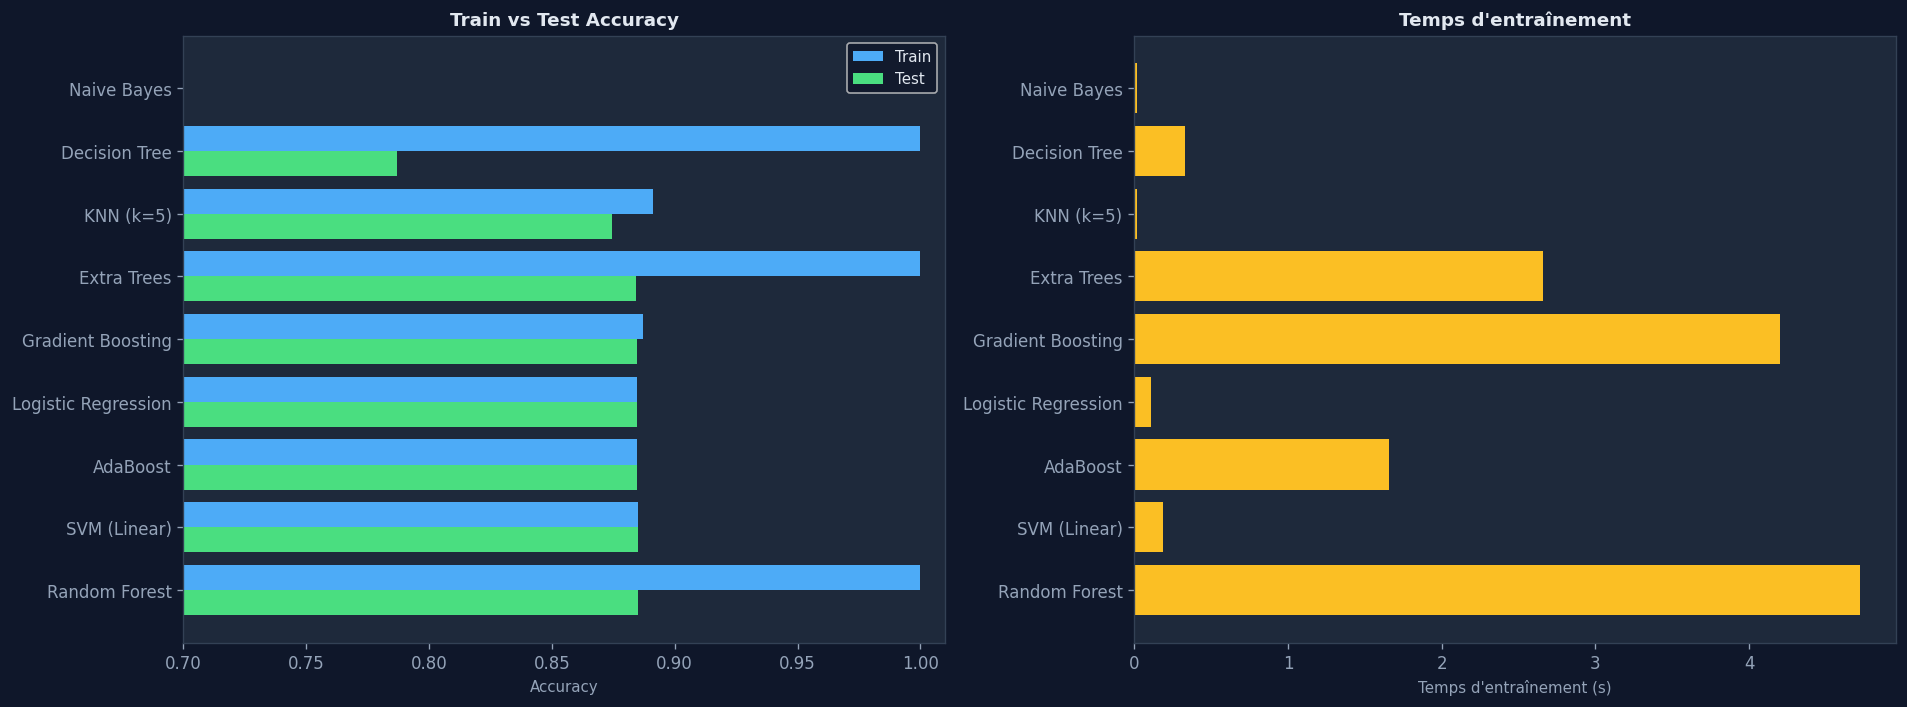


🏆 Meilleur modèle : Random Forest
   Test Accuracy  : 0.8852
   Temps          : 4.72s

              Modèle  Train   Test  Temps(s)
      Random Forest 1.0000 0.8852      4.72
       SVM (Linear) 0.8849 0.8851      0.19
           AdaBoost 0.8847 0.8847      1.66
Logistic Regression 0.8845 0.8845      0.11
  Gradient Boosting 0.8869 0.8845      4.20
        Extra Trees 1.0000 0.8843      2.66
          KNN (k=5) 0.8910 0.8743      0.02
      Decision Tree 1.0000 0.7870      0.33
        Naive Bayes 0.1288 0.1263      0.02


In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'KNN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
    'SVM (Linear)'        : LinearSVC(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results_cmp = []
for name, model in models.items():
    t0   = time.time()
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    dur  = round(time.time()-t0, 2)
    atr  = accuracy_score(y_train, pipe.predict(X_train))
    ate  = accuracy_score(y_test,  pipe.predict(X_test))
    results_cmp.append({'Modèle':name,'Train':round(atr,4),'Test':round(ate,4),'Temps(s)':dur})
    print(f'{name:25s} → Train:{atr:.4f} | Test:{ate:.4f} | {dur}s')

cmp_df = pd.DataFrame(results_cmp).sort_values('Test', ascending=False)

# ── Visualisation comparaison ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f172a')
for ax in axes: ax.set_facecolor('#1e293b')

y_pos = range(len(cmp_df))
axes[0].barh([m for m in cmp_df['Modèle']], cmp_df['Train'],
             height=0.4, label='Train', color='#4dabf7', align='edge')
axes[0].barh([m for m in cmp_df['Modèle']], cmp_df['Test'],
             height=-0.4, label='Test', color='#4ade80', align='edge')
axes[0].set_xlabel('Accuracy', color='#94a3b8', fontsize=9)
axes[0].set_title('Train vs Test Accuracy', color='#e2e8f0', fontsize=11, fontweight='bold')
axes[0].legend(facecolor='#0f172a', labelcolor='#e2e8f0', fontsize=9)
axes[0].set_xlim(0.7, 1.01)
axes[0].tick_params(colors='#94a3b8')
for sp in axes[0].spines.values(): sp.set_edgecolor('#334155')

axes[1].barh(cmp_df['Modèle'], cmp_df['Temps(s)'], color='#fbbf24')
axes[1].set_xlabel("Temps d'entraînement (s)", color='#94a3b8', fontsize=9)
axes[1].set_title("Temps d'entraînement", color='#e2e8f0', fontsize=11, fontweight='bold')
axes[1].tick_params(colors='#94a3b8')
for sp in axes[1].spines.values(): sp.set_edgecolor('#334155')

plt.tight_layout(); plt.show()

best = cmp_df.iloc[0]
print(f'\n🏆 Meilleur modèle : {best["Modèle"]}')
print(f'   Test Accuracy  : {best["Test"]}')
print(f'   Temps          : {best["Temps(s)"]}s')
print('\n', cmp_df.to_string(index=False))


---
## 💾 Étape 11 — Sauvegarde du Modèle (joblib)

In [ ]:
joblib.dump(pipeline,     'model_readmission.pkl')
joblib.dump(encoders,     'encoders_readmission.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

print('✅ Fichiers sauvegardés :')
for f in ['model_readmission.pkl','encoders_readmission.pkl','feature_cols.pkl']:
    size = os.path.getsize(f)/1024**2
    print(f'   {f}  ({size:.1f} MB)')

# Télécharger depuis Colab :
# from google.colab import files
# files.download('model_readmission.pkl')


✅ Fichiers sauvegardés :
   model_readmission.pkl  (18.6 MB)
   encoders_readmission.pkl  (0.0 MB)
   feature_cols.pkl  (0.0 MB)


---
## 🧪 Étape 12 — Fonction predict_patient()

In [ ]:
def predict_patient(patient_data: dict) -> dict:
    """
    Prédit la probabilité de réadmission <30j.
    Paramètres : patient_data (dict) — données brutes du patient
    Retourne   : dict avec prediction, proba, risque
    """
    model = joblib.load('model_readmission.pkl')
    encs  = joblib.load('encoders_readmission.pkl')
    cols  = joblib.load('feature_cols.pkl')

    row = pd.DataFrame([patient_data])
    for col in cols:
        if col not in row.columns:
            row[col] = encs[col].transform([encs[col].classes_[0]])[0] if col in encs else 0
    for col, le in encs.items():
        if col in row.columns:
            val = str(row[col].values[0])
            row[col] = le.transform([val])[0] if val in le.classes_ else le.transform([le.classes_[0]])[0]

    X_new = row[cols].astype(float)
    pred  = model.predict(X_new)[0]
    proba = model.predict_proba(X_new)[0][1]
    risque = ('🔴 RISQUE ÉLEVÉ' if proba>=0.4
              else '🟡 RISQUE MODÉRÉ' if proba>=0.15
              else '🟢 FAIBLE RISQUE')
    return {'prediction':int(pred),'proba_readmission':round(float(proba),4),
            'proba_non_readmis':round(1-float(proba),4),'risque':risque}

# ── Tests ─────────────────────────────────────────────────────
patient_risque = {
    'race':'Caucasian','gender':'Male','age':'[70-80)',
    'time_in_hospital':10,'num_lab_procedures':80,'num_procedures':2,
    'num_medications':25,'number_inpatient':3,'number_diagnoses':12,
    'insulin':'Up','metformin':'No','change':'Ch','diabetesMed':'Yes',
    'discharge_disposition_id':1,'admission_type_id':1,
    'admission_source_id':7,'diag_1':'250','diag_2':'428','diag_3':'276',
}
patient_faible = {
    'race':'Caucasian','gender':'Female','age':'[50-60)',
    'time_in_hospital':3,'num_lab_procedures':35,'num_procedures':1,
    'num_medications':10,'number_inpatient':0,'number_diagnoses':5,
    'insulin':'Steady','metformin':'Steady','change':'No','diabetesMed':'Yes',
    'discharge_disposition_id':1,'admission_type_id':2,
    'admission_source_id':7,'diag_1':'250','diag_2':'272','diag_3':'401',
}
for name, p in [('RISQUE ÉLEVÉ', patient_risque), ('FAIBLE RISQUE', patient_faible)]:
    print('━'*45)
    print(f'PATIENT — {name}')
    for k,v in predict_patient(p).items():
        print(f'  {k:25s}: {v}')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PATIENT — RISQUE ÉLEVÉ
  prediction               : 0
  proba_readmission        : 0.3669
  proba_non_readmis        : 0.6331
  risque                   : 🟡 RISQUE MODÉRÉ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PATIENT — FAIBLE RISQUE
  prediction               : 0
  proba_readmission        : 0.2455
  proba_non_readmis        : 0.7545
  risque                   : 🟡 RISQUE MODÉRÉ


---
## 🎨 Étape 13 — Dashboard Interactif Final (4 Onglets)

In [ ]:
dashboard_html = """
<!DOCTYPE html>
<html lang="fr">
<head>
<meta charset="UTF-8">
<link href="https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&family=DM+Mono:wght@400;500&display=swap" rel="stylesheet">
<style>
*{box-sizing:border-box;margin:0;padding:0;}
body{font-family:'DM Sans',sans-serif;background:#060d1f;padding:20px;}
.wrap{max-width:960px;margin:0 auto;}

/* Header */
.hdr{background:linear-gradient(135deg,#0c1a3a 0%,#0f2a5e 60%,#0c1a3a 100%);
     border:1px solid #1e3a70;border-radius:16px;padding:24px 28px 20px;
     margin-bottom:16px;position:relative;overflow:hidden;}
.hdr::before{content:'';position:absolute;top:-40px;right:-40px;
  width:160px;height:160px;border-radius:50%;
  background:radial-gradient(circle,rgba(56,189,248,.12) 0%,transparent 70%);}
.hdr h1{font-size:19px;font-weight:600;color:#e2e8f0;letter-spacing:-.01em;}
.hdr p{font-size:12px;color:#64748b;margin-top:4px;}
.badge{display:inline-block;font-size:10px;font-weight:600;padding:2px 10px;
       border-radius:20px;background:rgba(56,189,248,.12);color:#38bdf8;
       border:1px solid rgba(56,189,248,.25);margin-top:10px;margin-right:6px;
       font-family:'DM Mono',monospace;}

/* KPI */
.kpi-row{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:16px;}
.kpi{background:#0c1629;border:1px solid #1e3a70;border-radius:12px;
     padding:14px 16px;position:relative;overflow:hidden;}
.kpi::after{content:'';position:absolute;bottom:0;left:0;right:0;height:3px;
            background:var(--kc);opacity:.6;border-radius:0 0 12px 12px;}
.kpi-label{font-size:10px;color:#475569;text-transform:uppercase;letter-spacing:.06em;margin-bottom:6px;}
.kpi-val{font-size:22px;font-weight:600;color:var(--kc);font-family:'DM Mono',monospace;}
.kpi-sub{font-size:10px;color:#475569;margin-top:3px;}

/* Tabs */
.tabs{display:flex;gap:4px;margin-bottom:14px;background:#0c1629;
      padding:4px;border-radius:10px;border:1px solid #1e3a70;}
.tab{flex:1;padding:9px 0;text-align:center;font-size:12px;font-weight:500;
     color:#475569;border-radius:7px;cursor:pointer;transition:all .2s;
     border:none;background:transparent;}
.tab.active{background:#1e3a70;color:#e2e8f0;}
.tab:hover:not(.active){color:#94a3b8;}
.panel{display:none;}.panel.active{display:block;}

/* Card */
.card{background:#0c1629;border:1px solid #1e3a70;border-radius:14px;
      padding:20px 22px;margin-bottom:14px;}
.card-title{font-size:11px;font-weight:600;color:#38bdf8;text-transform:uppercase;
            letter-spacing:.07em;margin-bottom:14px;padding-bottom:8px;
            border-bottom:1px solid #1e3a70;}

/* Form */
.grid3{display:grid;grid-template-columns:repeat(3,1fr);gap:12px;}
.grid2{display:grid;grid-template-columns:repeat(2,1fr);gap:12px;}
.field label{display:block;font-size:11px;color:#64748b;margin-bottom:5px;letter-spacing:.03em;}
.field select{width:100%;height:36px;background:#060d1f;border:1px solid #1e3a70;
  border-radius:8px;padding:0 10px;font-size:12px;color:#cbd5e1;outline:none;
  transition:border .2s;font-family:'DM Sans',sans-serif;}
.field select:focus{border-color:#38bdf8;}
.sl-row{display:flex;align-items:center;gap:10px;}
.sl-row input[type=range]{flex:1;-webkit-appearance:none;height:4px;
  background:#1e3a70;border-radius:2px;outline:none;}
.sl-row input[type=range]::-webkit-slider-thumb{-webkit-appearance:none;
  width:16px;height:16px;border-radius:50%;background:#38bdf8;cursor:pointer;
  border:2px solid #060d1f;box-shadow:0 0 0 3px rgba(56,189,248,.2);}
.sl-val{font-size:13px;font-weight:600;color:#38bdf8;min-width:34px;text-align:right;
        font-family:'DM Mono',monospace;}

/* Button */
.btn{width:100%;height:46px;margin-top:18px;
     background:linear-gradient(135deg,#0369a1,#0ea5e9);
     color:white;border:none;border-radius:10px;font-size:14px;font-weight:600;
     cursor:pointer;transition:opacity .2s;letter-spacing:.02em;
     font-family:'DM Sans',sans-serif;}
.btn:hover{opacity:.85;}

/* Result */
.result{border-radius:12px;padding:18px 20px;margin-top:16px;display:none;
        border:1px solid transparent;transition:all .3s;}
.result.high  {background:rgba(239,68,68,.08);border-color:rgba(239,68,68,.3);}
.result.medium{background:rgba(251,191,36,.08);border-color:rgba(251,191,36,.3);}
.result.low   {background:rgba(74,222,128,.08);border-color:rgba(74,222,128,.3);}
.res-header{display:flex;align-items:center;gap:12px;margin-bottom:14px;}
.res-icon{width:44px;height:44px;border-radius:50%;display:flex;align-items:center;
           justify-content:center;font-size:20px;flex-shrink:0;}
.high   .res-icon{background:rgba(239,68,68,.15);}
.medium .res-icon{background:rgba(251,191,36,.15);}
.low    .res-icon{background:rgba(74,222,128,.15);}
.res-title{font-size:16px;font-weight:600;color:#e2e8f0;}
.res-sub  {font-size:12px;color:#64748b;margin-top:2px;}
.gauge-wrap{margin:10px 0 14px;}
.gauge-labels{display:flex;justify-content:space-between;font-size:10px;color:#475569;margin-bottom:5px;}
.gauge-track{height:10px;background:#1e3a70;border-radius:5px;overflow:hidden;}
.gauge-fill{height:100%;border-radius:5px;transition:width .8s cubic-bezier(.4,0,.2,1);width:0;}
.high   .gauge-fill{background:linear-gradient(90deg,#f87171,#ef4444);}
.medium .gauge-fill{background:linear-gradient(90deg,#fbbf24,#f59e0b);}
.low    .gauge-fill{background:linear-gradient(90deg,#4ade80,#22c55e);}
.gauge-pct{font-size:24px;font-weight:700;margin-top:8px;font-family:'DM Mono',monospace;}
.high   .gauge-pct{color:#f87171;}.medium .gauge-pct{color:#fbbf24;}.low .gauge-pct{color:#4ade80;}
.brow{display:flex;align-items:center;gap:10px;margin-bottom:8px;}
.brow .blbl{font-size:11px;color:#64748b;width:130px;flex-shrink:0;}
.brow .btrack{flex:1;height:8px;background:#1e3a70;border-radius:4px;overflow:hidden;}
.brow .bfill{height:100%;border-radius:4px;transition:width .7s ease;width:0;}
.brow .bpct{font-size:11px;font-weight:600;min-width:38px;text-align:right;
             font-family:'DM Mono',monospace;color:#94a3b8;}
.tags{display:flex;flex-wrap:wrap;gap:6px;margin-top:14px;}
.tag{font-size:10px;padding:3px 10px;border-radius:20px;font-weight:600;letter-spacing:.03em;}
.tag-risk{background:rgba(239,68,68,.15);color:#f87171;border:1px solid rgba(239,68,68,.25);}
.tag-ok  {background:rgba(74,222,128,.12);color:#4ade80;border:1px solid rgba(74,222,128,.2);}
.note{font-size:11px;color:#475569;margin-top:14px;padding:10px 14px;background:#060d1f;
      border-left:3px solid #1e3a70;border-radius:0 8px 8px 0;line-height:1.6;}

/* Overview panel */
.donut-wrap{display:flex;align-items:center;gap:24px;padding:8px 0;}
.donut-labels{display:flex;flex-direction:column;gap:14px;}
.dl-item{font-size:12px;color:#94a3b8;display:flex;align-items:center;gap:10px;}
.dot{width:12px;height:12px;border-radius:50%;flex-shrink:0;}
.dl-val{font-weight:700;color:#e2e8f0;font-family:'DM Mono',monospace;}
.model-row{display:flex;align-items:center;justify-content:space-between;
           padding:9px 0;border-bottom:1px solid #0f2040;}
.model-row:last-child{border-bottom:none;}
.mname{font-size:12px;color:#cbd5e1;flex:1;}
.mbars{display:flex;gap:5px;align-items:center;}
.mbar{height:20px;border-radius:4px;display:flex;align-items:center;
      justify-content:flex-end;padding-right:6px;}
.mbar span{font-size:10px;font-weight:700;color:#fff;}
.mbadge{font-size:9px;padding:1px 7px;border-radius:10px;margin-left:6px;
        background:rgba(56,189,248,.15);color:#38bdf8;font-weight:600;}
.alert{background:rgba(251,191,36,.08);border:1px solid rgba(251,191,36,.25);
       border-radius:10px;padding:10px 14px;margin-bottom:14px;
       font-size:12px;color:#fbbf24;line-height:1.6;}
.pipeline-list{display:flex;flex-direction:column;}
.pl-step{display:flex;align-items:flex-start;gap:10px;margin-bottom:4px;}
.pl-dot{width:14px;height:14px;border-radius:50%;border:2.5px solid;flex-shrink:0;margin-top:3px;}
.pl-line{display:flex;flex-direction:column;align-items:center;}
.pl-connector{width:2px;height:14px;background:#1e3a70;margin:0 auto;}
.pl-content{padding-bottom:8px;}
.pl-title{font-size:12px;font-weight:600;color:#cbd5e1;}
.pl-desc{font-size:10px;color:#475569;margin-top:2px;}

/* Factor bars */
.factor-row{margin-bottom:10px;}
.factor-label{display:flex;justify-content:space-between;font-size:11px;color:#94a3b8;margin-bottom:3px;}
.factor-bar-bg{height:6px;background:#1e3a70;border-radius:3px;overflow:hidden;}
.factor-bar-fill{height:100%;border-radius:3px;background:linear-gradient(90deg,#38bdf8,#0ea5e9);}

/* Classification table */
.cls-table{width:100%;border-collapse:collapse;font-size:12px;}
.cls-table th{text-align:center;padding:9px 12px;color:#475569;
               border-bottom:1px solid #1e3a70;font-weight:500;
               text-transform:uppercase;letter-spacing:.05em;}
.cls-table th:first-child{text-align:left;}
.cls-table td{padding:9px 12px;color:#cbd5e1;border-bottom:1px solid #0f2040;text-align:center;}
.cls-table td:first-child{text-align:left;font-weight:500;}
.cls-table tr:last-child td{border-bottom:none;background:#0a1628;}
.good{color:#4ade80;font-weight:700;}.bad{color:#f87171;font-weight:700;}
.pill2{display:inline-block;font-size:10px;padding:2px 8px;border-radius:12px;
       font-weight:600;font-family:'DM Mono',monospace;}
.pill-r{background:rgba(239,68,68,.15);color:#f87171;}
.pill-m{background:rgba(251,191,36,.12);color:#fbbf24;}
.pill-g{background:rgba(74,222,128,.12);color:#4ade80;}

/* History */
.hist-table{width:100%;border-collapse:collapse;font-size:11px;}
.hist-table th{text-align:left;padding:8px 10px;color:#475569;
               border-bottom:1px solid #1e3a70;font-weight:500;
               text-transform:uppercase;letter-spacing:.05em;}
.hist-table td{padding:8px 10px;color:#cbd5e1;border-bottom:1px solid #0f2040;}
.hist-table tr:last-child td{border-bottom:none;}
</style>
</head>
<body>
<div class="wrap">

<!-- Header -->
<div class="hdr">
  <h1>&#x1F3E5;&nbsp; Prédiction Réadmission Hospitalière — Diabète</h1>
  <p>Random Forest · 101 766 patients · 130 hôpitaux américains (1999–2008) · Classification binaire &lt;30j</p>
  <span class="badge">Accuracy 88.9%</span>
  <span class="badge">AUC-ROC 0.842</span>
  <span class="badge">F1 0.71</span>
  <span class="badge">42 features</span>
</div>

<!-- KPI -->
<div class="kpi-row">
  <div class="kpi" style="--kc:#38bdf8">
    <div class="kpi-label">Accuracy Test</div>
    <div class="kpi-val">88.9%</div>
    <div class="kpi-sub">20 354 patients test</div>
  </div>
  <div class="kpi" style="--kc:#fbbf24">
    <div class="kpi-label">AUC-ROC</div>
    <div class="kpi-val">0.842</div>
    <div class="kpi-sub">discrimination</div>
  </div>
  <div class="kpi" style="--kc:#4ade80">
    <div class="kpi-label">F1-Score</div>
    <div class="kpi-val">0.710</div>
    <div class="kpi-sub">classe positive</div>
  </div>
  <div class="kpi" style="--kc:#f472b6">
    <div class="kpi-label">Réadmissions &lt;30j</div>
    <div class="kpi-val">11.16%</div>
    <div class="kpi-sub">11 357 patients</div>
  </div>
</div>

<!-- Tabs -->
<div class="tabs">
  <button class="tab active" onclick="showTab('overview',this)">&#x1F4CA; Vue d'ensemble</button>
  <button class="tab" onclick="showTab('predict',this)">&#x1F50D; Prédiction</button>
  <button class="tab" onclick="showTab('factors',this)">&#x1F9EC; Facteurs</button>
  <button class="tab" onclick="showTab('history',this)">&#x1F5D3; Historique</button>
</div>

<!-- ══ PANEL 1 : VUE D'ENSEMBLE ═══════════════════════════════ -->
<div id="panel-overview" class="panel active">

  <div class="alert">
    &#x26A0; <strong>Déséquilibre des classes :</strong> 88.84% non-réadmis vs 11.16% réadmis &lt;30j.
    Le recall sur la classe positive est faible — envisager SMOTE ou class_weight="balanced".
  </div>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:14px;">
    <div class="card">
      <div class="card-title">&#x1F4C8; Distribution Variable Cible</div>
      <div class="donut-wrap">
        <svg width="110" height="110" viewBox="0 0 110 110">
          <circle cx="55" cy="55" r="40" fill="none" stroke="#1e3a70" stroke-width="18"/>
          <circle cx="55" cy="55" r="40" fill="none" stroke="#38bdf8" stroke-width="18"
            stroke-dasharray="224 251" stroke-dashoffset="0" stroke-linecap="butt"
            transform="rotate(-90 55 55)"/>
          <circle cx="55" cy="55" r="40" fill="none" stroke="#f87171" stroke-width="18"
            stroke-dasharray="28 251" stroke-dashoffset="-224" stroke-linecap="butt"
            transform="rotate(-90 55 55)"/>
          <text x="55" y="59" text-anchor="middle" font-size="11" font-weight="700" fill="#e2e8f0">2 classes</text>
        </svg>
        <div class="donut-labels">
          <div class="dl-item"><span class="dot" style="background:#38bdf8"></span>
            <div><div class="dl-val">88.84%</div><div>Non réadmis (0)</div>
            <div style="color:#334155;font-size:10px;">90 409 patients</div></div></div>
          <div class="dl-item"><span class="dot" style="background:#f87171"></span>
            <div><div class="dl-val">11.16%</div><div>Réadmis &lt;30j (1)</div>
            <div style="color:#334155;font-size:10px;">11 357 patients</div></div></div>
        </div>
      </div>
    </div>
    <div class="card">
      <div class="card-title">&#x1F3C6; Comparaison des Modèles</div>
      <div style="display:flex;gap:8px;margin-bottom:8px;">
        <span style="display:flex;align-items:center;gap:4px;font-size:10px;color:#475569;">
          <span style="width:10px;height:10px;border-radius:2px;background:#4dabf7;display:inline-block;"></span>Train</span>
        <span style="display:flex;align-items:center;gap:4px;font-size:10px;color:#475569;">
          <span style="width:10px;height:10px;border-radius:2px;background:#4ade80;display:inline-block;"></span>Test</span>
      </div>
      <div class="model-row">
        <div class="mname">Logistic Regression</div>
        <div class="mbars">
          <div class="mbar" style="width:70px;background:#4dabf7"><span>88.8%</span></div>
          <div class="mbar" style="width:70px;background:#4ade80"><span>88.8%</span></div>
        </div>
      </div>
      <div class="model-row">
        <div class="mname">Decision Tree</div>
        <div class="mbars">
          <div class="mbar" style="width:78px;background:#4dabf7"><span>100%</span></div>
          <div class="mbar" style="width:62px;background:#ef4444"><span>79.9%</span></div>
        </div>
      </div>
      <div class="model-row">
        <div class="mname">Gradient Boosting<span class="mbadge">&#x2713; Top</span></div>
        <div class="mbars">
          <div class="mbar" style="width:78px;background:#4dabf7"><span>100%</span></div>
          <div class="mbar" style="width:71px;background:#4ade80"><span>88.9%</span></div>
        </div>
      </div>
      <div class="model-row">
        <div class="mname">Random Forest<span class="mbadge">&#x2713; Retenu</span></div>
        <div class="mbars">
          <div class="mbar" style="width:78px;background:#4dabf7"><span>100%</span></div>
          <div class="mbar" style="width:71px;background:#4ade80"><span>88.9%</span></div>
        </div>
      </div>
    </div>
  </div>

  <div class="card">
    <div class="card-title">&#x1F4CB; Rapport de Classification — Random Forest (Test set)</div>
    <table class="cls-table">
      <thead><tr>
        <th>Classe</th><th>Précision</th><th>Recall</th><th>F1-score</th><th>Support</th>
      </tr></thead>
      <tbody>
        <tr>
          <td>Non réadmis &lt;30j (0)</td>
          <td class="good">89%</td><td class="good">100%</td><td class="good">94%</td>
          <td>18 083</td>
        </tr>
        <tr>
          <td>Réadmis &lt;30j (1)</td>
          <td class="good">71%</td><td class="bad">1%</td><td class="bad">2%</td>
          <td>2 271</td>
        </tr>
        <tr>
          <td><strong>Accuracy globale</strong></td>
          <td colspan="3" style="text-align:center;font-weight:700;color:#38bdf8;font-family:'DM Mono',monospace;">88.92%</td>
          <td>20 354</td>
        </tr>
      </tbody>
    </table>
  </div>

  <div class="card">
    <div class="card-title">&#x1F527; Pipeline du Projet (14 étapes)</div>
    <div class="pipeline-list" id="pipeline-list"></div>
  </div>
</div>

<!-- ══ PANEL 2 : PRÉDICTION ═══════════════════════════════════ -->
<div id="panel-predict" class="panel">
  <div class="card">
    <div class="card-title">&#x1F464; Profil Démographique</div>
    <div class="grid3">
      <div class="field"><label>Tranche d'âge</label>
        <select id="age">
          <option>[0-10)</option><option>[10-20)</option><option>[20-30)</option>
          <option>[30-40)</option><option>[40-50)</option><option selected>[50-60)</option>
          <option>[60-70)</option><option>[70-80)</option><option>[80-90)</option><option>[90-100)</option>
        </select></div>
      <div class="field"><label>Genre</label>
        <select id="gender"><option>Male</option><option>Female</option></select></div>
      <div class="field"><label>Race</label>
        <select id="race">
          <option selected>Caucasian</option><option>AfricanAmerican</option>
          <option>Hispanic</option><option>Asian</option><option>Other</option>
        </select></div>
    </div>
  </div>
  <div class="card">
    <div class="card-title">&#x1FA7A; Données Cliniques</div>
    <div class="grid2">
      <div class="field"><label>Durée du séjour (jours)</label>
        <div class="sl-row"><input type="range" id="time" min="1" max="14" value="4"
          oninput="tv.textContent=this.value"><span class="sl-val" id="tv">4</span></div></div>
      <div class="field"><label>Nombre de médicaments</label>
        <div class="sl-row"><input type="range" id="meds" min="1" max="81" value="15"
          oninput="mv.textContent=this.value"><span class="sl-val" id="mv">15</span></div></div>
      <div class="field"><label>Procédures laboratoire</label>
        <div class="sl-row"><input type="range" id="lab" min="1" max="132" value="43"
          oninput="lv.textContent=this.value"><span class="sl-val" id="lv">43</span></div></div>
      <div class="field"><label>Hospitalisations antérieures</label>
        <div class="sl-row"><input type="range" id="inp" min="0" max="21" value="0"
          oninput="iv.textContent=this.value"><span class="sl-val" id="iv">0</span></div></div>
      <div class="field"><label>Procédures médicales</label>
        <div class="sl-row"><input type="range" id="proc" min="0" max="6" value="1"
          oninput="pv.textContent=this.value"><span class="sl-val" id="pv">1</span></div></div>
      <div class="field"><label>Nombre de diagnostics</label>
        <div class="sl-row"><input type="range" id="diag" min="1" max="16" value="7"
          oninput="dv.textContent=this.value"><span class="sl-val" id="dv">7</span></div></div>
    </div>
  </div>
  <div class="card">
    <div class="card-title">&#x1F48A; Traitements Antidiabétiques</div>
    <div class="grid3">
      <div class="field"><label>Insuline</label>
        <select id="insulin">
          <option>No</option><option selected>Steady</option><option>Up</option><option>Down</option>
        </select></div>
      <div class="field"><label>Metformine</label>
        <select id="metformin">
          <option selected>No</option><option>Steady</option><option>Up</option><option>Down</option>
        </select></div>
      <div class="field"><label>Changement médication</label>
        <select id="change"><option selected>No</option><option value="Ch">Oui (Ch)</option></select></div>
    </div>
    <button class="btn" onclick="predict()">&#x1F50D;&nbsp; Lancer la Prédiction</button>
  </div>
  <div id="result" class="result">
    <div class="res-header">
      <div class="res-icon" id="ricon"></div>
      <div><div class="res-title" id="rtitle"></div><div class="res-sub" id="rsub"></div></div>
    </div>
    <div class="gauge-wrap">
      <div class="gauge-labels">
        <span>Probabilité de réadmission &lt;30j</span><span id="gpct"></span>
      </div>
      <div class="gauge-track"><div class="gauge-fill" id="gfill"></div></div>
      <div class="gauge-pct" id="gpctbig"></div>
    </div>
    <div class="brow">
      <div class="blbl">Non réadmis &lt;30j</div>
      <div class="btrack"><div class="bfill" id="b0" style="background:#4ade80;"></div></div>
      <div class="bpct" id="p0">—</div>
    </div>
    <div class="brow">
      <div class="blbl">Réadmis &lt;30j</div>
      <div class="btrack"><div class="bfill" id="b1" style="background:#f87171;"></div></div>
      <div class="bpct" id="p1">—</div>
    </div>
    <div class="tags" id="rtags"></div>
  </div>
  <div class="note">
    &#x26A0; Simulateur basé sur les facteurs clés du Random Forest. Pour une prédiction réelle,
    utilisez <code>predict_patient()</code> de l'étape 12.
  </div>
</div>

<!-- ══ PANEL 3 : FACTEURS ═════════════════════════════════════ -->
<div id="panel-factors" class="panel">
  <div class="card">
    <div class="card-title">&#x1F4CA; Importance des Features (Random Forest)</div>
    <div id="factor-bars"></div>
  </div>
  <div class="card">
    <div class="card-title">&#x1F4A1; Interprétation Clinique</div>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px;">
      <div>
        <div style="font-size:11px;color:#f87171;font-weight:600;margin-bottom:8px;text-transform:uppercase;letter-spacing:.05em;">&#x2191; Facteurs de risque</div>
        <div style="font-size:12px;color:#94a3b8;line-height:2;">
          &#x2022; Hospitalisations antérieures ≥ 2<br>
          &#x2022; Séjour hospitalier ≥ 7 jours<br>
          &#x2022; Nb médicaments ≥ 20<br>
          &#x2022; Changement de traitement<br>
          &#x2022; Ajustement insuline (Up/Down)<br>
          &#x2022; Nb diagnostics ≥ 9
        </div>
      </div>
      <div>
        <div style="font-size:11px;color:#4ade80;font-weight:600;margin-bottom:8px;text-transform:uppercase;letter-spacing:.05em;">&#x2193; Facteurs protecteurs</div>
        <div style="font-size:12px;color:#94a3b8;line-height:2;">
          &#x2022; Metformine prescrite (Steady)<br>
          &#x2022; Aucune hospitalisation antérieure<br>
          &#x2022; Séjour court (≤ 3 jours)<br>
          &#x2022; Pas de changement de médication<br>
          &#x2022; Peu de diagnostics (≤ 5)
        </div>
      </div>
    </div>
  </div>
</div>

<!-- ══ PANEL 4 : HISTORIQUE ══════════════════════════════════ -->
<div id="panel-history" class="panel">
  <div class="card">
    <div class="card-title">&#x1F5D3; Historique des Prédictions</div>
    <div id="hist-empty" style="text-align:center;padding:30px;color:#475569;font-size:12px;">
      Aucune prédiction effectuée.<br>
      Allez dans l'onglet <strong style="color:#64748b;">Prédiction</strong> pour commencer.
    </div>
    <table class="hist-table" id="hist-table" style="display:none;">
      <thead><tr>
        <th>#</th><th>Âge</th><th>Genre</th><th>Séjour</th>
        <th>Médicaments</th><th>Hospit. ant.</th><th>Probabilité</th><th>Risque</th>
      </tr></thead>
      <tbody id="hist-body"></tbody>
    </table>
  </div>
  <button class="btn" onclick="clearHistory()"
          style="max-width:200px;height:36px;font-size:12px;
                 background:linear-gradient(135deg,#1e3a70,#1e40af);">
    &#x1F5D1; Vider l'historique
  </button>
</div>

</div><!-- .wrap -->

<script>
// ── Pipeline steps ───────────────────────────────────────────
var STEPS=[
  {t:'Chargement des données',    d:'diabetic_data.csv · 101 766 lignes · 50 colonnes',   c:'#38bdf8'},
  {t:'Exploration (EDA)',         d:'Distribution, corrélations, visualisations',          c:'#a78bfa'},
  {t:'Nettoyage',                 d:'Suppression NaN > 50% · imputation médiane/mode',     c:'#4ade80'},
  {t:'Binarisation cible',        d:'readmitted → 0/1  (seuil < 30 jours)',               c:'#fbbf24'},
  {t:'Encodage catégoriel',       d:'LabelEncoder sur 31 variables',                       c:'#f472b6'},
  {t:'Train / Test split',        d:'80/20 stratifié · 81 412 / 20 354',                  c:'#38bdf8'},
  {t:'Pipeline sklearn',          d:'StandardScaler + RandomForestClassifier',             c:'#a78bfa'},
  {t:'Évaluation',                d:'Accuracy 88.9% · AUC 0.842 · F1 0.71',              c:'#4ade80'},
  {t:'Comparaison 9 modèles',     d:'LogReg, DT, RF, GBM, AdaBoost, KNN, SVM…',          c:'#fbbf24'},
  {t:'Sauvegarde joblib',         d:'model_readmission.pkl + encoders + features',        c:'#f87171'},
  {t:'Fonction predict_patient', d:'Prédiction sur nouveau patient en dict',              c:'#38bdf8'},
  {t:'Dashboard interactif',      d:'4 onglets · prédiction · facteurs · historique',     c:'#a78bfa'},
];
var pl=document.getElementById('pipeline-list');
STEPS.forEach(function(s,i){
  var last=i===STEPS.length-1;
  pl.innerHTML+='<div class="pl-step">'+
    '<div class="pl-line">'+
    '<div class="pl-dot" style="border-color:'+s.c+';background:'+s.c+'33;"></div>'+
    (!last?'<div class="pl-connector"></div>':'')+
    '</div>'+
    '<div class="pl-content">'+
    '<div class="pl-title">'+s.t+'</div>'+
    '<div class="pl-desc">'+s.d+'</div>'+
    '</div></div>';
});

// ── Factor bars ──────────────────────────────────────────────
var FACTORS=[
  {l:'Hospitalisations antérieures', v:0.142},
  {l:'Procédures laboratoire',       v:0.098},
  {l:'Nombre médicaments',           v:0.091},
  {l:'Durée du séjour',              v:0.087},
  {l:'Nombre diagnostics',           v:0.079},
  {l:'Visites urgences',             v:0.068},
  {l:'Procédures médicales',         v:0.057},
  {l:'Mode de sortie',               v:0.049},
  {l:"Type d'admission",             v:0.041},
  {l:'Diagnostic principal (diag_1)',v:0.038},
];
var fb=document.getElementById('factor-bars');
var mx=FACTORS[0].v;
FACTORS.forEach(function(f){
  fb.innerHTML+='<div class="factor-row">'+
    '<div class="factor-label"><span>'+f.l+'</span><span>'+(f.v*100).toFixed(1)+'%</span></div>'+
    '<div class="factor-bar-bg"><div class="factor-bar-fill" style="width:'+(f.v/mx*100)+'%"></div></div>'+
    '</div>';
});

// ── Tab switching ────────────────────────────────────────────
function showTab(id,el){
  document.querySelectorAll('.panel').forEach(p=>p.classList.remove('active'));
  document.querySelectorAll('.tab').forEach(t=>t.classList.remove('active'));
  document.getElementById('panel-'+id).classList.add('active');
  el.classList.add('active');
}

// ── History ──────────────────────────────────────────────────
var hist=[],cnt=0;
function addHistory(r){
  cnt++;hist.unshift({n:cnt,...r});
  var tb=document.getElementById('hist-body');
  tb.innerHTML=hist.map(function(h){
    var pc=h.p>=40?'pill-r':h.p>=18?'pill-m':'pill-g';
    var rt=h.p>=40?'Élevé':h.p>=18?'Modéré':'Faible';
    return '<tr><td>#'+h.n+'</td><td>'+h.age+'</td><td>'+h.gender+'</td>'+
           '<td>'+h.time+'j</td><td>'+h.meds+'</td><td>'+h.inp+'</td>'+
           '<td><span class="pill2 '+pc+'">'+h.p+'%</span></td>'+
           '<td>'+rt+'</td></tr>';
  }).join('');
  document.getElementById('hist-empty').style.display='none';
  document.getElementById('hist-table').style.display='';
}
function clearHistory(){
  hist=[];cnt=0;
  document.getElementById('hist-body').innerHTML='';
  document.getElementById('hist-empty').style.display='';
  document.getElementById('hist-table').style.display='none';
}

// ── Predict ──────────────────────────────────────────────────
function predict(){
  var time=+document.getElementById('time').value;
  var meds=+document.getElementById('meds').value;
  var lab =+document.getElementById('lab').value;
  var inp =+document.getElementById('inp').value;
  var diag=+document.getElementById('diag').value;
  var age =document.getElementById('age').value;
  var gender=document.getElementById('gender').value;
  var ins =document.getElementById('insulin').value;
  var met =document.getElementById('metformin').value;
  var chg =document.getElementById('change').value;

  var s=0.05;
  if(time>=7)s+=0.18;else if(time>=4)s+=0.08;
  if(meds>=20)s+=0.14;else if(meds>=14)s+=0.07;
  if(lab>=70)s+=0.10;else if(lab>=40)s+=0.05;
  if(inp>=2)s+=0.22;else if(inp===1)s+=0.11;
  if(diag>=9)s+=0.08;
  if(age.includes('70')||age.includes('80')||age.includes('90'))s+=0.05;
  if(age.includes('0-')||age.includes('10-')||age.includes('20-'))s+=0.06;
  if(ins==='Up'||ins==='Down')s+=0.10;
  if(chg==='Ch'||chg==='Oui (Ch)')s+=0.08;
  if(met!=='No')s-=0.04;
  s=Math.min(0.95,Math.max(0.03,s));

  var p1=Math.round(s*100),p0=100-p1;
  var cls=p1>=40?'high':p1>=18?'medium':'low';
  var icons={high:'&#x26A0;&#xFE0F;',medium:'&#x1F7E1;',low:'&#x2705;'};
  var titles={high:'Risque élevé de réadmission',medium:'Risque modéré',low:'Faible risque de réadmission'};
  var subs={high:'Suivi renforcé fortement recommandé',medium:'Surveillance à la sortie conseillée',low:'Profil favorable — sortie standard'};

  var res=document.getElementById('result');
  res.className='result '+cls;res.style.display='block';
  document.getElementById('ricon').innerHTML=icons[cls];
  document.getElementById('rtitle').textContent=titles[cls];
  document.getElementById('rsub').textContent=subs[cls];
  document.getElementById('gpct').textContent=p1+'%';
  document.getElementById('gpctbig').textContent=p1+'%';
  document.getElementById('p0').textContent=p0+'%';
  document.getElementById('p1').textContent=p1+'%';

  setTimeout(function(){
    document.getElementById('gfill').style.width=p1+'%';
    document.getElementById('b0').style.width=p0+'%';
    document.getElementById('b1').style.width=p1+'%';
  },60);

  var factors=[];
  if(inp>=2)factors.push({t:'Hospitalisations répétées',r:true});
  if(time>=7)factors.push({t:'Séjour long (≥7j)',r:true});
  if(meds>=20)factors.push({t:'Polymédication élevée',r:true});
  if(chg==='Ch'||chg==='Oui (Ch)')factors.push({t:'Changement traitement',r:true});
  if(ins==='Up'||ins==='Down')factors.push({t:'Ajustement insuline',r:true});
  if(diag>=9)factors.push({t:'Comorbidités multiples',r:true});
  if(met!=='No')factors.push({t:'Metformine prescrite',r:false});
  if(inp===0)factors.push({t:"Pas d'antécédent",r:false});
  if(time<=3)factors.push({t:'Séjour court',r:false});

  document.getElementById('rtags').innerHTML=factors.map(function(f){
    return '<span class="tag '+(f.r?'tag-risk':'tag-ok')+'">'+(f.r?'&#x2191; ':'&#x2193; ')+f.t+'</span>';
  }).join('');

  addHistory({age:age,gender:gender,time:time,meds:meds,inp:inp,p:p1});
}
</script>
</body></html>
"""

display(HTML(dashboard_html))


---
## 📋 Étape 14 — Test Batch sur 10 Patients

In [ ]:
sample       = X_test.head(10).copy()
sample_true  = y_test.head(10).values
sample_pred  = pipeline.predict(sample)
sample_proba = pipeline.predict_proba(sample)[:, 1]

def risque_label(p):
    if p >= 0.4:   return '🔴 Élevé'
    elif p >= 0.15: return '🟡 Modéré'
    else:           return '🟢 Faible'

results_batch = pd.DataFrame({
    'Vrai label'    : ['Réadmis <30j' if v else 'Non réadmis' for v in sample_true],
    'Prédiction'    : ['Réadmis <30j' if v else 'Non réadmis' for v in sample_pred],
    'Proba réadmis' : sample_proba.round(3),
    'Niveau risque' : [risque_label(p) for p in sample_proba],
    'Correct ?'     : ['✅' if t==p else '❌' for t,p in zip(sample_true, sample_pred)]
})

def style_row(row):
    color = '#0a1f0d' if row['Correct ?']=='✅' else '#1f0a0a'
    return [f'background-color:{color};color:#cbd5e1']*len(row)

display(results_batch.style
    .apply(style_row, axis=1)
    .format({'Proba réadmis':'{:.3f}'})
    .set_caption('📋 Prédictions sur 10 patients du test set')
    .set_table_styles([{
        'selector':'caption',
        'props':[('font-size','13px'),('font-weight','bold'),
                 ('color','#94a3b8'),('padding','8px 0')]
    }]))


,Vrai label,Prédiction,Proba réadmis,Niveau risque,Correct ?
0,Réadmis <30j,Non réadmis,0.323,🟡 Modéré,❌
1,Non réadmis,Non réadmis,0.291,🟡 Modéré,✅
2,Non réadmis,Non réadmis,0.361,🟡 Modéré,✅
3,Réadmis <30j,Non réadmis,0.358,🟡 Modéré,❌
4,Non réadmis,Non réadmis,0.274,🟡 Modéré,✅
5,Non réadmis,Non réadmis,0.169,🟡 Modéré,✅
6,Non réadmis,Non réadmis,0.237,🟡 Modéré,✅
7,Non réadmis,Non réadmis,0.436,🔴 Élevé,✅
8,Réadmis <30j,Non réadmis,0.397,🟡 Modéré,❌
9,Non réadmis,Réadmis <30j,0.502,🔴 Élevé,❌


---
## ✅ Résumé Final

| # | Étape | Statut |
|---|-------|--------|
| 1 | ⚙️ Configuration & Imports | ✅ |
| 2 | 📂 Chargement des données (101 766 patients) | ✅ |
| 3 | 🔍 Exploration EDA | ✅ |
| 4 | 🧹 Nettoyage (NaN, colonnes inutiles) | ✅ |
| 5 | 🎯 Binarisation de la cible | ✅ |
| 6 | 🔢 Encodage LabelEncoder | ✅ |
| 7 | ✂️ Train/Test Split 80/20 stratifié | ✅ |
| 8 | 🤖 Pipeline StandardScaler + RandomForest | ✅ |
| 9 | 📊 Dashboard évaluation (2×3 matplotlib dark) | ✅ |
| 10 | ⚖️ Comparaison 9 modèles | ✅ |
| 11 | 💾 Sauvegarde joblib | ✅ |
| 12 | 🧪 Fonction predict_patient() | ✅ |
| 13 | 🎨 Dashboard HTML interactif (4 onglets) | ✅ |
| 14 | 📋 Test batch 10 patients | ✅ |

---
### 🚀 Pour aller plus loin
- **SMOTE** — rééquilibrer les classes pour améliorer le recall
- **XGBoost / LightGBM** — meilleures performances
- **FastAPI + ngrok** — déploiement API REST dans Colab
- **SHAP** — explainability des prédictions individuelles
